In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

In [65]:
# === 1. Load data ===
df_train = pd.read_csv("customer_feedback_labeled_balanced.csv")  # asli + dummy
df_test = pd.read_csv("customer_feedback_labeled_final_cleaned.csv")  # hanya asli

In [9]:
# Hapus baris yang 100% identik
df_test = df_test.drop_duplicates().reset_index(drop=True)

In [66]:
df_test.shape

(280, 9)

## NLP

Batches: 100%|██████████| 9/9 [00:00<00:00,  9.06it/s]


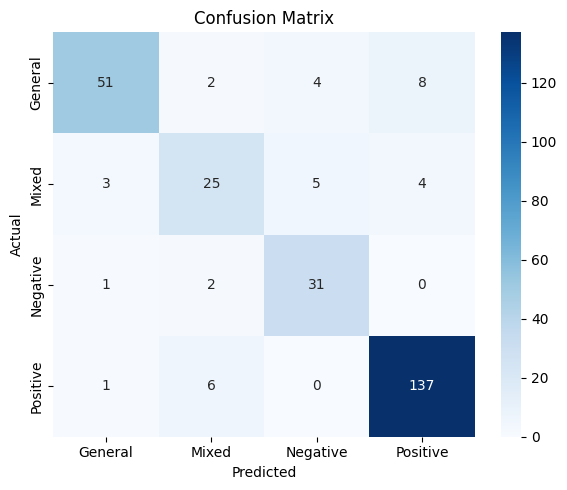

=== Classification Report ===
              precision    recall  f1-score   support

     General       0.91      0.78      0.84        65
       Mixed       0.71      0.68      0.69        37
    Negative       0.78      0.91      0.84        34
    Positive       0.92      0.95      0.94       144

    accuracy                           0.87       280
   macro avg       0.83      0.83      0.83       280
weighted avg       0.87      0.87      0.87       280



In [67]:
# === 2. Gabungkan label Informative ke General (jika masih ada)
df_test['new_label_refined'] = df_test['new_label_refined'].replace("Informative", "General")

# === 3. Encode label
le = LabelEncoder()
df_train['label_encoded'] = le.fit_transform(df_train['new_label_refined'])
df_test['label_encoded'] = le.transform(df_test['new_label_refined'])

# === 4. Embedding dengan BERT
model = SentenceTransformer('all-MiniLM-L6-v2')
X_train = model.encode(df_train['Comments'].tolist(), show_progress_bar=True)
y_train = df_train['label_encoded'].values

X_test = model.encode(df_test['Comments'].tolist(), show_progress_bar=True)
y_test = df_test['label_encoded'].values

# === 5. Train Model
clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# === 6. Predict & Evaluate
y_pred = clf.predict(X_test)
labels = le.inverse_transform(sorted(set(y_test)))

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=labels))

In [14]:
# 1. Load Data
df_train_full = pd.read_csv("customer_feedback_labeled_balanced.csv")
df_test_full = pd.read_csv("customer_feedback_labeled_final_cleaned.csv")

# 2. Gabungkan Informative jadi General (kalau masih ada)
df_train_full['new_label_refined'] = df_train_full['new_label_refined'].replace("Informative", "General")
df_test_full['new_label_refined'] = df_test_full['new_label_refined'].replace("Informative", "General")

# 3. Label Encoding
le = LabelEncoder()
df_train_full['label_encoded'] = le.fit_transform(df_train_full['new_label_refined'])
df_test_full['label_encoded'] = le.transform(df_test_full['new_label_refined'])

# 4. Embedding semua komentar
model = SentenceTransformer('all-MiniLM-L6-v2')
X_train_all = model.encode(df_train_full['Comments'].tolist(), show_progress_bar=True)
y_train_all = df_train_full['label_encoded'].values

X_test = model.encode(df_test_full['Comments'].tolist(), show_progress_bar=True)
y_test = df_test_full['label_encoded'].values

# 5. Siapkan dataframe embedding
train_data = pd.DataFrame({'text': df_train_full['Comments'], 'label': y_train_all.tolist()})
train_data['embedding'] = list(X_train_all)

# 6. Inisialisasi: ambil 100 data acak sebagai data latih awal
np.random.seed(42)
initial_idx = np.random.choice(train_data.index, size=100, replace=False)
current_train = train_data.loc[initial_idx].copy()
remaining_data = train_data.drop(index=initial_idx)

# 7. Loop iteratif
results = []
for iteration in range(5):
    X = np.vstack(current_train['embedding'].values)
    y = current_train['label'].values

    clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    clf.fit(X, y)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((iteration+1, acc, len(current_train)))

    # Cek kesalahan dari sisa data
    rem_X = np.vstack(remaining_data['embedding'].values)
    rem_y = remaining_data['label'].values
    rem_pred = clf.predict(rem_X)

    wrong_idx = np.where(rem_pred != rem_y)[0]
    if len(wrong_idx) == 0:
        break

    # Tambahkan maksimal 50 yang salah ke training berikutnya
    n_next = min(50, len(wrong_idx))
    add_idx = remaining_data.iloc[wrong_idx[:n_next]].index
    current_train = pd.concat([current_train, remaining_data.loc[add_idx]])
    remaining_data = remaining_data.drop(index=add_idx)

# 8. Lihat hasil
results_df = pd.DataFrame(results, columns=["Iterasi", "Akurasi", "Jumlah Data Latih"])
print("=== Hasil Iteratif Training ===")
print(results_df)

Batches: 100%|██████████| 9/9 [00:00<00:00, 11.73it/s]

=== Hasil Iteratif Training ===
   Iterasi   Akurasi  Jumlah Data Latih
0        1  0.725000                100
1        2  0.850000                150
2        3  0.942857                177
3        4  0.939286                180
4        5  0.942857                182


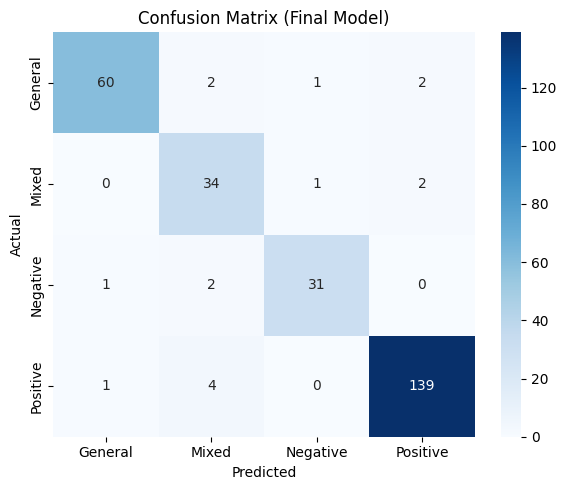

=== Classification Report ===
              precision    recall  f1-score   support

     General       0.97      0.92      0.94        65
       Mixed       0.81      0.92      0.86        37
    Negative       0.94      0.91      0.93        34
    Positive       0.97      0.97      0.97       144

    accuracy                           0.94       280
   macro avg       0.92      0.93      0.92       280
weighted avg       0.95      0.94      0.94       280



In [15]:
# === 9. Latih model akhir dari data current_train ===
X_final = np.vstack(current_train['embedding'].values)
y_final = current_train['label'].values

final_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
final_clf.fit(X_final, y_final)

# === 10. Prediksi di test set
y_test_pred = final_clf.predict(X_test)
labels = le.inverse_transform(sorted(set(y_test)))

# === 11. Confusion Matrix dan Classification Report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d',
            xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Final Model)")
plt.tight_layout()
plt.show()

# Laporan
print("=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=labels))


In [31]:
def predict_with_fallback(comment, model, classifier, label_encoder):
    comment_lower = comment.lower()
    if 'pro' in comment_lower or 'cons' in comment_lower:
        return 'Mixed'

    # BERT prediction
    vector = model.encode([comment])
    pred_class_index = classifier.predict(vector)[0]
    pred_label = label_encoder.inverse_transform([pred_class_index])[0]
    return pred_label

In [ ]:
from termcolor import colored

In [40]:
def predict_many_comments(comments, model, classifier, label_encoder):
    vectors = model.encode(comments)
    predictions = classifier.predict(vectors)
    labels = label_encoder.inverse_transform(predictions)
    
    for i, (text, label) in enumerate(zip(comments, labels)):
        print("="*60)
        print(colored(f"💬 Komentar {i+1}:", "yellow"), f"\"{text}\"")
        print(colored("🎯 Prediksi Label:", "green", attrs=["bold"]), f"{label.upper()}")
        print("="*60)

# Contoh pakai
predict_many_comments(
    ["pro camera good, cons battery bad", "ok","this phone is really good","bad resolution ew"],
    model=model,
    classifier=final_clf,
    label_encoder=le
)


💬 Komentar 1: "pro camera good, cons battery bad"
🎯 Prediksi Label: MIXED
💬 Komentar 2: "ok"
🎯 Prediksi Label: GENERAL
💬 Komentar 3: "this phone is really good"
🎯 Prediksi Label: POSITIVE
💬 Komentar 4: "bad resolution ew"
🎯 Prediksi Label: NEGATIVE


## ANALISIS TAMBAHAN

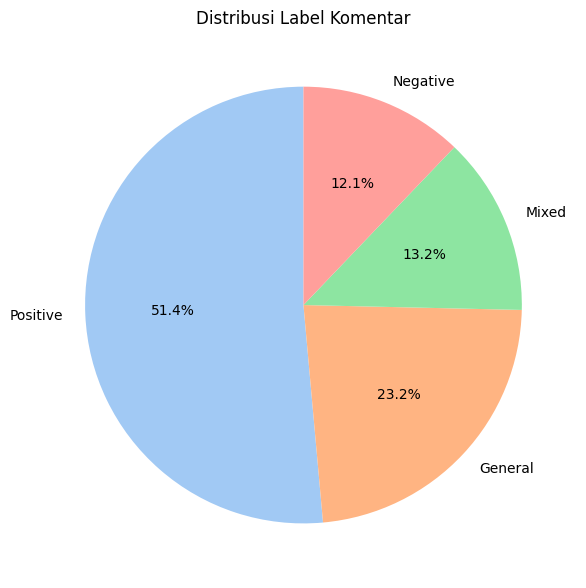

C:\Users\71485\AppData\Local\Temp\ipykernel_19784\3468644681.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Rating_clean', data=df, palette="Blues")


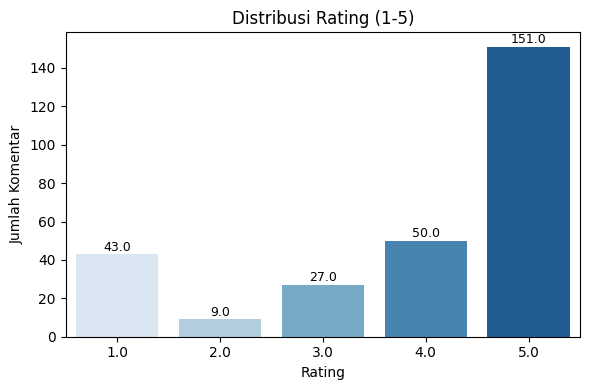

C:\Users\71485\AppData\Local\Temp\ipykernel_19784\3468644681.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


C:\Users\71485\AppData\Local\Temp\ipykernel_19784\3468644681.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='Weekday', data=df, order=[


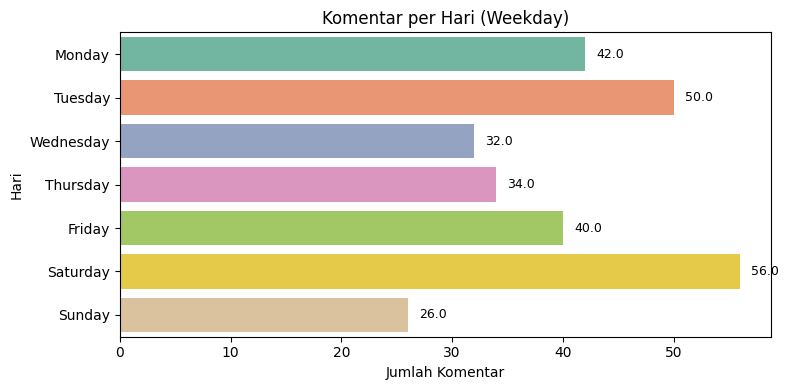

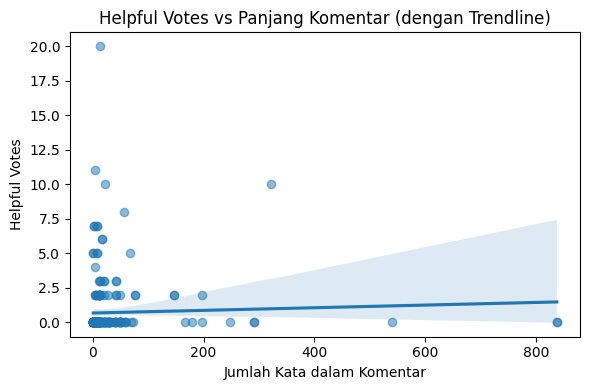

C:\Users\71485\AppData\Local\Temp\ipykernel_19784\3468644681.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Length_Group', y='Helpful_votes', data=df, palette="coolwarm")


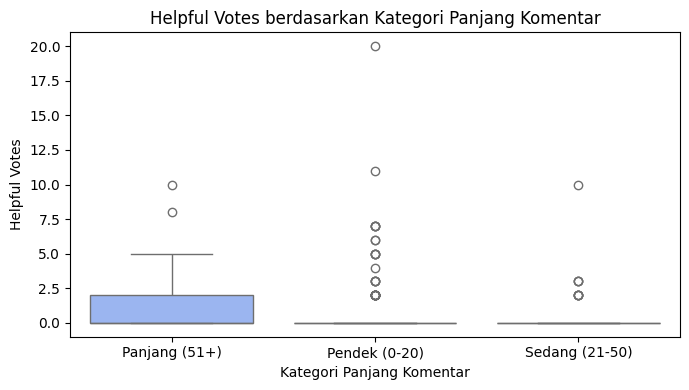

Korelasi antara panjang komentar dan helpful votes: 0.04


In [43]:
# Install jika dibutuhkan
# !pip install seaborn matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import pearsonr

# === 1. Load Data ===
df = pd.read_csv("customer_feedback_labeled_final_cleaned.csv")

# === 2. Preprocessing ===
# Bersihkan kolom Rating ke angka
df['Rating_clean'] = df['Rating'].str.extract(r"([0-5](?:\.\d)?)").astype(float)

# Ekstrak angka dari kolom Useful
df['Helpful_votes'] = df['Useful'].str.extract(r'(\d+)').fillna(0).astype(int)

# Hitung panjang komentar (jumlah kata)
df['Comment_length'] = df['Comments'].astype(str).apply(lambda x: len(x.split()))

# Ubah kolom Date ke datetime
df['Date_clean'] = pd.to_datetime(df['Date'].str.replace("on ", ""), errors='coerce')

# Ambil bulan dan nama hari
df['Month'] = df['Date_clean'].dt.to_period('M')
df['Weekday'] = df['Date_clean'].dt.day_name()

# Label sudah ada di kolom: new_label_refined
df['Sentiment'] = df['new_label_refined']

# === 3. Visualisasi ===

# Pie Chart Distribusi Label
plt.figure(figsize=(6, 6))
df['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title("Distribusi Label Komentar")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Bar Chart Distribusi Rating
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Rating_clean', data=df, palette="Blues")
plt.title("Distribusi Rating (1-5)")
plt.xlabel("Rating")
plt.ylabel("Jumlah Komentar")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=9, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.tight_layout()
plt.show()

# Line Chart Komentar per Bulan
plt.figure(figsize=(10, 4))
monthly_counts = df.groupby('Month').size()
ax = monthly_counts.plot(marker='o', color='teal')
for i, value in enumerate(monthly_counts):
    ax.text(i, value + 1, str(value), ha='center', va='bottom', fontsize=9)
plt.title("Jumlah Komentar per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Komentar")
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar Chart Komentar per Hari
plt.figure(figsize=(8, 4))
ax = sns.countplot(y='Weekday', data=df, order=[
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
], palette="Set2")
plt.title("Komentar per Hari (Weekday)")
plt.xlabel("Jumlah Komentar")
plt.ylabel("Hari")
for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_width() + 1, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Enhanced Scatterplot Helpful Votes vs Panjang Komentar + Trendline
plt.figure(figsize=(6, 4))
sns.regplot(x='Comment_length', y='Helpful_votes', data=df, scatter_kws={'alpha':0.5})
plt.title("Helpful Votes vs Panjang Komentar (dengan Trendline)")
plt.xlabel("Jumlah Kata dalam Komentar")
plt.ylabel("Helpful Votes")
plt.tight_layout()
plt.show()

# Boxplot Helpful Votes berdasarkan kategori panjang komentar
def length_category(length):
    if length <= 20:
        return 'Pendek (0-20)'
    elif length <= 50:
        return 'Sedang (21-50)'
    else:
        return 'Panjang (51+)'

df['Length_Group'] = df['Comment_length'].apply(length_category)

plt.figure(figsize=(7, 4))
sns.boxplot(x='Length_Group', y='Helpful_votes', data=df, palette="coolwarm")
plt.title("Helpful Votes berdasarkan Kategori Panjang Komentar")
plt.xlabel("Kategori Panjang Komentar")
plt.ylabel("Helpful Votes")
plt.tight_layout()
plt.show()

# Korelasi Pearson antara panjang komentar dan helpful votes
corr, _ = pearsonr(df['Comment_length'], df['Helpful_votes'])
print(f"Korelasi antara panjang komentar dan helpful votes: {corr:.2f}")

In [45]:
pip install textblob

  Obtaining dependency information for textblob from https://files.pythonhosted.org/packages/1e/d6/40aa5aead775582ea0cf35870e5a3f16fab4b967f1ad2debe675f673f923/textblob-0.19.0-py3-none-any.whl.metadata
  Obtaining dependency information for nltk>=3.9 from https://files.pythonhosted.org/packages/4d/66/7d9e26593edda06e8cb531874633f7c2372279c3b0f46235539fe546df8b/nltk-3.9.1-py3-none-any.whl.metadata
  Obtaining dependency information for click from https://files.pythonhosted.org/packages/85/32/10bb5764d90a8eee674e9dc6f4db6a0ab47c8c4d0d83c27f7c39ac415a4d/click-8.2.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
    --------------------------------------- 10.2/624.3 kB ? eta -:--:--
   --- ----------------------------------- 61.4/624.3 kB 812.7 kB/s eta 0:00:01
   ----------------- ---------------------- 276.5/624.3 kB 2.8 MB/s eta 0:00:01
   ---------------------------------- ----- 532.5/624.3 kB 4.2 MB/s eta 0:00:01
   -------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\71485\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\71485\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

In [49]:
pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/b9/74/6a15f68f59bc90032bfcf62eca796a5675be95e1aaf84f7861e1bfcfa8e5/wordcloud-1.9.4-cp312-cp312-win_amd64.whl.metadata
   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/301.2 kB ? eta -:--:--
   ----- --------------------------------- 41.0/301.2 kB 487.6 kB/s eta 0:00:01
   ------------------------------- -------- 235.5/301.2 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 301.2/301.2 kB 2.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


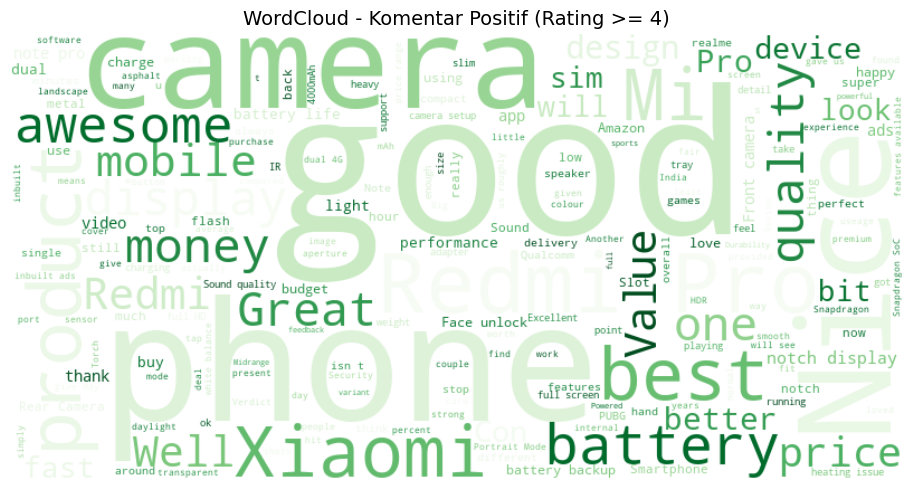

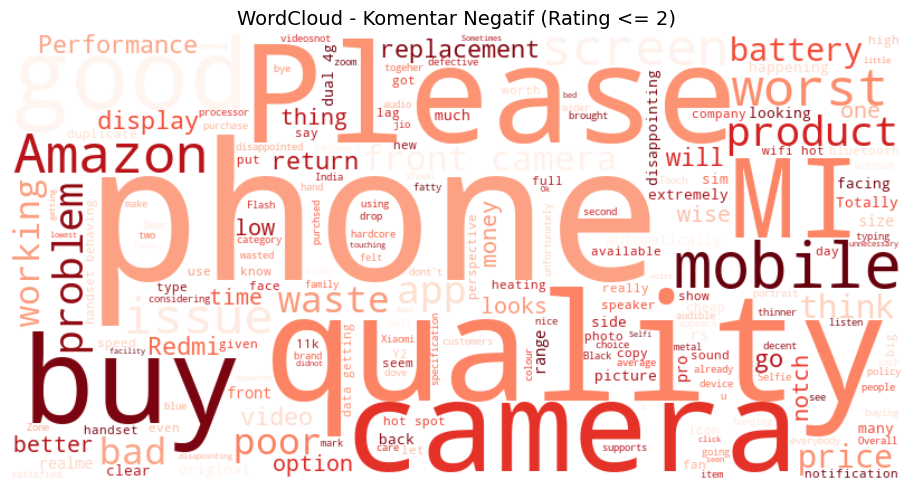

C:\Users\71485\AppData\Local\Temp\ipykernel_19784\573801328.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_pos, palette='Greens_r')


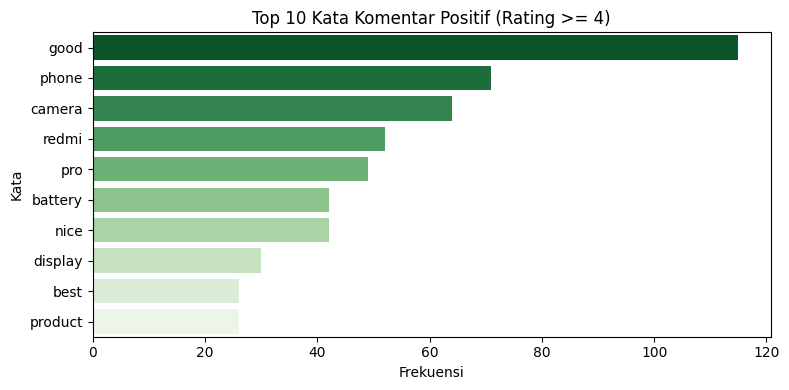

C:\Users\71485\AppData\Local\Temp\ipykernel_19784\573801328.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata', data=df_neg, palette='Reds_r')


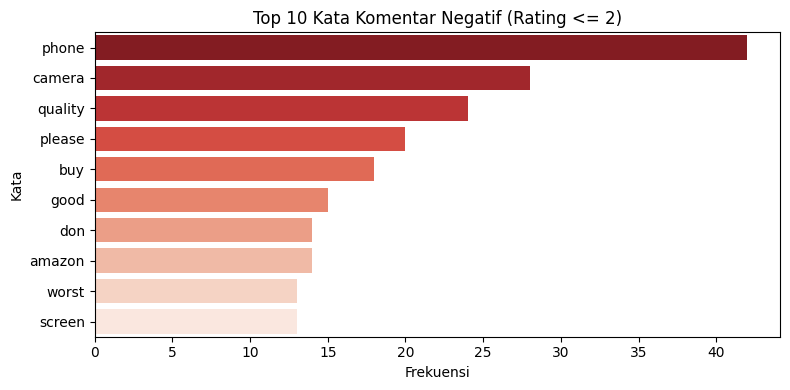

In [53]:
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re
from scipy.stats import pearsonr
from textblob import TextBlob

# === 1. Load Data ===
df = pd.read_csv("customer_feedback_labeled_final_cleaned.csv")

# === 2. Preprocessing ===
df['Rating_clean'] = df['Rating'].str.extract(r"([0-5](?:\.\d)?)").astype(float)
df['Helpful_votes'] = df['Useful'].str.extract(r'(\d+)').fillna(0).astype(int)
df['Comment_length'] = df['Comments'].astype(str).apply(lambda x: len(x.split()))
df['Date_clean'] = pd.to_datetime(df['Date'].str.replace("on ", ""), errors='coerce')
df['Month'] = df['Date_clean'].dt.to_period('M')
df['Weekday'] = df['Date_clean'].dt.day_name()
df['Sentiment'] = df['new_label_refined']

# === 3. WordCloud Komentar Positif vs Negatif Berdasarkan Rating ===
def generate_wordcloud(text, title, colormap):
    stopwords = set(STOPWORDS)
    wc = WordCloud(width=800, height=400, background_color='white', colormap=colormap, stopwords=stopwords).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Gabungkan komentar jadi 1 string per kategori rating
positive_comments = " ".join(df[df['Rating_clean'] >= 4]['Comments'].dropna().astype(str))
negative_comments = " ".join(df[df['Rating_clean'] <= 2]['Comments'].dropna().astype(str))

# Tampilkan wordcloud dengan colormap berbeda
generate_wordcloud(positive_comments, "WordCloud - Komentar Positif (Rating >= 4)", colormap='Greens')
generate_wordcloud(negative_comments, "WordCloud - Komentar Negatif (Rating <= 2)", colormap='Reds')

# === 4. Bar Chart Top 10 Kata Positif dan Negatif ===
def get_top_words(text, n=10):
    stopwords = set(STOPWORDS)
    words = [word for word in re.findall(r"\b\w{3,}\b", text.lower()) if word not in stopwords]
    return Counter(words).most_common(n)

# Ambil top 10 kata
top_positive = get_top_words(positive_comments)
top_negative = get_top_words(negative_comments)

# Konversi ke DataFrame
df_pos = pd.DataFrame(top_positive, columns=['Kata', 'Frekuensi'])
df_neg = pd.DataFrame(top_negative, columns=['Kata', 'Frekuensi'])

# Plot Positif
plt.figure(figsize=(8, 4))
sns.barplot(x='Frekuensi', y='Kata', data=df_pos, palette='Greens_r')
plt.title("Top 10 Kata Komentar Positif (Rating >= 4)")
plt.tight_layout()
plt.show()

# Plot Negatif
plt.figure(figsize=(8, 4))
sns.barplot(x='Frekuensi', y='Kata', data=df_neg, palette='Reds_r')
plt.title("Top 10 Kata Komentar Negatif (Rating <= 2)")
plt.tight_layout()
plt.show()

=== Top 10 Kata Pujian vs Keluhan Berdasarkan Rating ===
  Kata_Pujian  Frekuensi Kata_Keluhan  Frekuensi
0        good        115        phone         42
1       phone         71       camera         28
2      camera         64      quality         24
3       redmi         52       please         20
4         pro         49          buy         18
5     battery         42         good         15
6        nice         42          don         14
7     display         30       amazon         14
8        best         26        worst         13
9     product         26       screen         13


C:\Users\71485\AppData\Local\Temp\ipykernel_19784\2446828325.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata_Pujian', data=df_pos, palette='Greens_r', ax=axes[0])
C:\Users\71485\AppData\Local\Temp\ipykernel_19784\2446828325.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frekuensi', y='Kata_Keluhan', data=df_neg, palette='Reds_r', ax=axes[1])


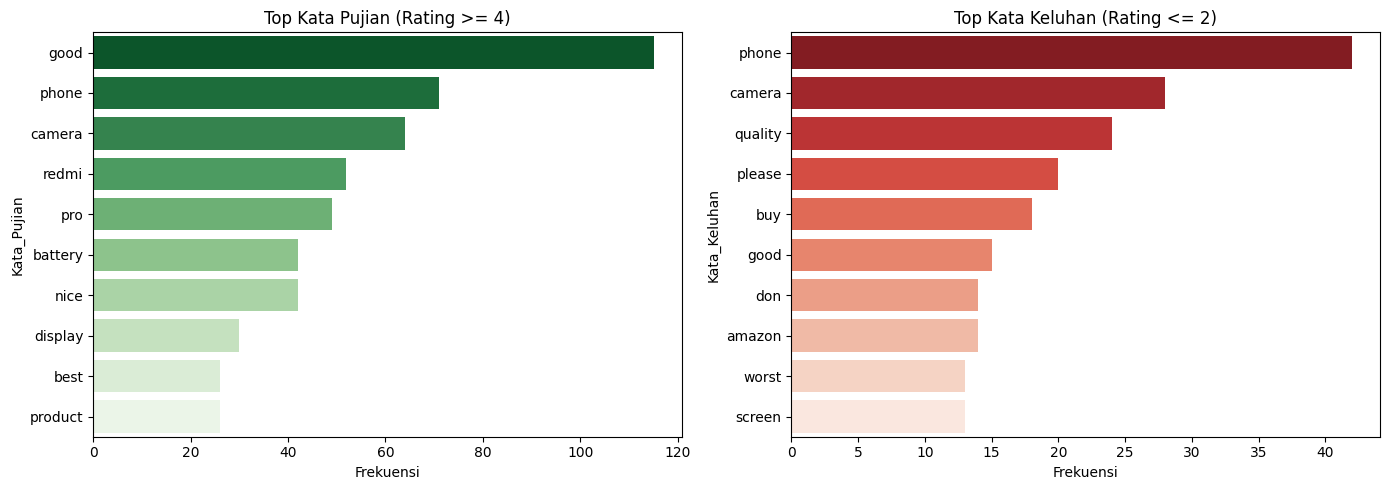

In [54]:
# === 1. Load Data ===
df = pd.read_csv("customer_feedback_labeled_final_cleaned.csv")

# === 2. Preprocessing ===
df['Rating_clean'] = df['Rating'].str.extract(r"([0-5](?:\.\d)?)").astype(float)
df['Helpful_votes'] = df['Useful'].str.extract(r'(\d+)').fillna(0).astype(int)
df['Comment_length'] = df['Comments'].astype(str).apply(lambda x: len(x.split()))
df['Date_clean'] = pd.to_datetime(df['Date'].str.replace("on ", ""), errors='coerce')
df['Month'] = df['Date_clean'].dt.to_period('M')
df['Weekday'] = df['Date_clean'].dt.day_name()
df['Sentiment'] = df['new_label_refined']

# === 3. Analisis Kata Pujian vs Keluhan Berdasarkan Rating ===
def get_top_words(text, n=10):
    stopwords = set(STOPWORDS)
    words = [word for word in re.findall(r"\b\w{3,}\b", text.lower()) if word not in stopwords]
    return Counter(words).most_common(n)

# Ambil komentar positif dan negatif
positive_comments = " ".join(df[df['Rating_clean'] >= 4]['Comments'].dropna().astype(str))
negative_comments = " ".join(df[df['Rating_clean'] <= 2]['Comments'].dropna().astype(str))

# Dapatkan 10 kata paling sering
top_positive = get_top_words(positive_comments, n=10)
top_negative = get_top_words(negative_comments, n=10)

# Konversi ke DataFrame
df_pos = pd.DataFrame(top_positive, columns=['Kata_Pujian', 'Frekuensi'])
df_neg = pd.DataFrame(top_negative, columns=['Kata_Keluhan', 'Frekuensi'])

# Gabungkan untuk tampilkan berdampingan
keyword_comparison = pd.concat([df_pos, df_neg], axis=1)
print("=== Top 10 Kata Pujian vs Keluhan Berdasarkan Rating ===")
print(keyword_comparison)

# Visualisasi Bar Chart Gabungan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='Frekuensi', y='Kata_Pujian', data=df_pos, palette='Greens_r', ax=axes[0])
axes[0].set_title("Top Kata Pujian (Rating >= 4)")
sns.barplot(x='Frekuensi', y='Kata_Keluhan', data=df_neg, palette='Reds_r', ax=axes[1])
axes[1].set_title("Top Kata Keluhan (Rating <= 2)")
plt.tight_layout()
plt.show()



🔍 Topik: CAMERA
Jumlah komentar negatif yang mengandung 'camera': 21
Kata-kata yang sering muncul bersama:
[('phone', 27), ('quality', 18), ('please', 13), ('front', 13), ('good', 10), ('poor', 9), ('amazon', 9), ('worst', 8), ('buy', 7), ('redmi', 7)]

🔍 Topik: QUALITY
Jumlah komentar negatif yang mengandung 'quality': 16
Kata-kata yang sering muncul bersama:
[('phone', 23), ('camera', 14), ('please', 13), ('amazon', 10), ('mobile', 8), ('poor', 8), ('buy', 7), ('problem', 7), ('handset', 6), ('bad', 6)]

🔍 Topik: AMAZON
Jumlah komentar negatif yang mengandung 'amazon': 8
Kata-kata yang sering muncul bersama:
[('phone', 26), ('quality', 12), ('will', 7), ('return', 7), ('please', 6), ('poor', 6), ('good', 5), ('working', 5), ('screen', 5), ('camera', 5)]


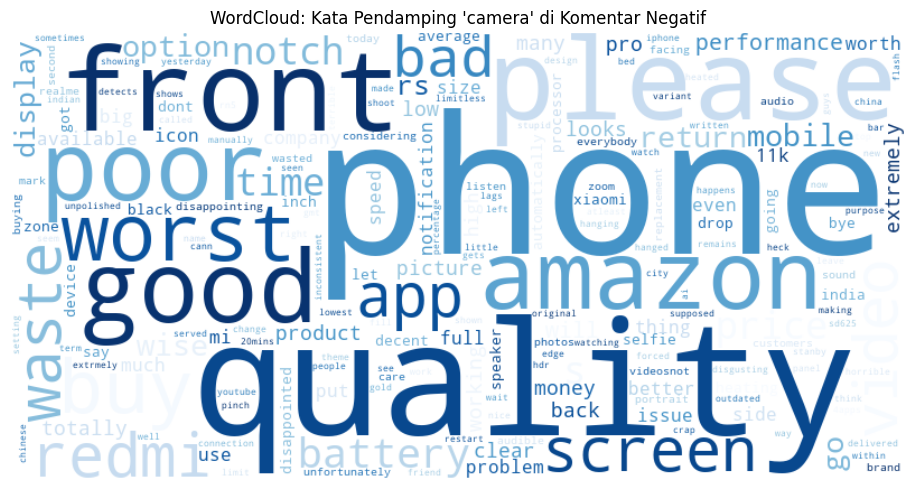

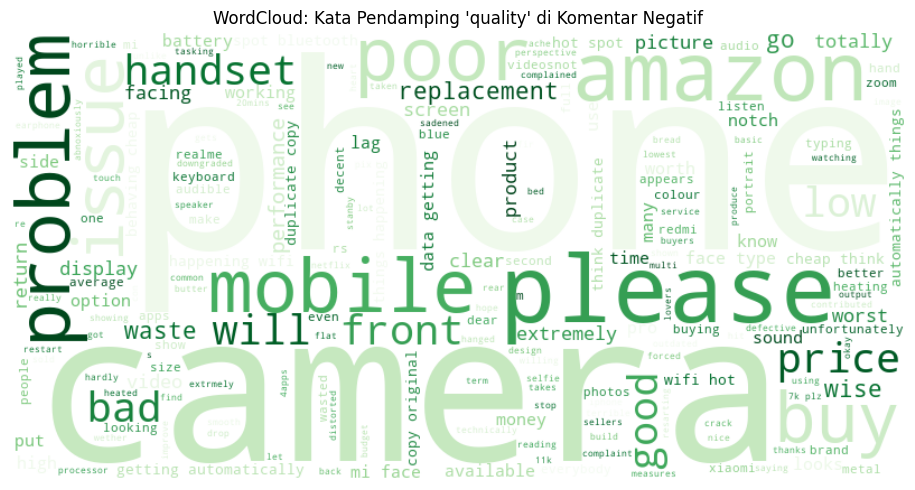

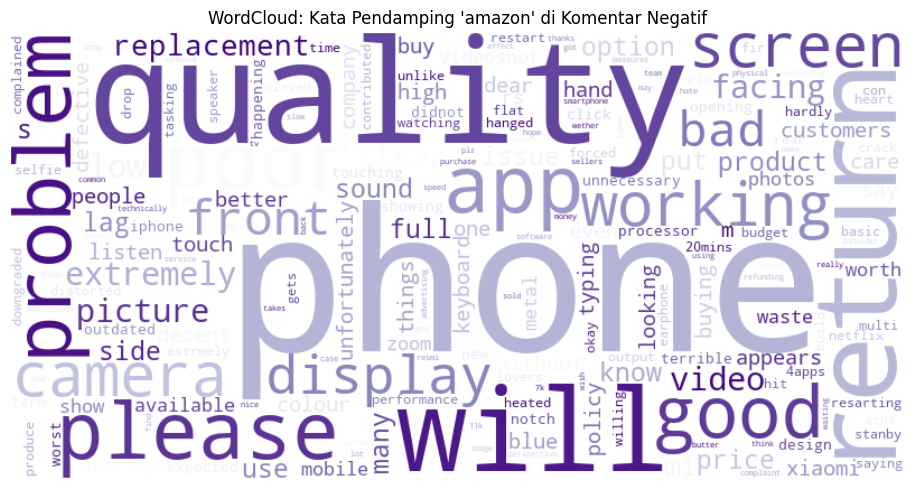

In [63]:
# === 1. Load Data ===
df = pd.read_csv("customer_feedback_labeled_final_cleaned.csv")

# === 2. Preprocessing ===
df['Rating_clean'] = df['Rating'].str.extract(r"([0-5](?:\.\d)?)").astype(float)
df['Helpful_votes'] = df['Useful'].str.extract(r'(\d+)').fillna(0).astype(int)
df['Comment_length'] = df['Comments'].astype(str).apply(lambda x: len(x.split()))
df['Date_clean'] = pd.to_datetime(df['Date'].str.replace("on ", ""), errors='coerce')
df['Month'] = df['Date_clean'].dt.to_period('M')
df['Weekday'] = df['Date_clean'].dt.day_name()
df['Sentiment'] = df['new_label_refined']

# === 3. Komentar Negatif yang Mengandung Kata Tertentu ===
def extract_comments_by_keyword(keyword, rating_threshold=2):
    pattern = re.compile(rf'\b{keyword}\b', re.IGNORECASE)
    return df[(df['Rating_clean'] <= rating_threshold) & df['Comments'].str.contains(pattern, na=False)]

keywords = ['camera', 'quality', 'amazon']
comment_sets = {key: extract_comments_by_keyword(key) for key in keywords}

# === 4. Hitung Kata Pendamping untuk Masing-masing Keyword ===
custom_stopwords = set(STOPWORDS).union({'t', 'don', 'didn', 'doesn', 'isn', 'wasn', 'wouldn'})

def get_common_co_words(df_subset, target_keyword, n=10):
    co_words = []
    for text in df_subset['Comments'].dropna().astype(str):
        words = re.findall(r'\b\w+\b', text.lower())
        if target_keyword in words:
            co_words.extend([w for w in words if w != target_keyword and w not in custom_stopwords])
    return Counter(co_words).most_common(n)

# === 5. Tampilkan Ringkasan ===
for key in keywords:
    print(f"\n🔍 Topik: {key.upper()}")
    print(f"Jumlah komentar negatif yang mengandung '{key}':", len(comment_sets[key]))
    print("Kata-kata yang sering muncul bersama:")
    print(get_common_co_words(comment_sets[key], key))

# === 6. (Revisi) WordCloud kata pendamping dengan warna beda per topik ===
def plot_co_wordcloud(keyword, colormap):
    df_kw = comment_sets[keyword]
    text = " ".join(df_kw['Comments'].dropna().astype(str).tolist())
    text_filtered = " ".join([w for w in re.findall(r'\b\w+\b', text.lower()) if w != keyword and w not in custom_stopwords])

    wc = WordCloud(width=800, height=400, background_color='white', colormap=colormap, stopwords=custom_stopwords).generate(text_filtered)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud: Kata Pendamping '{keyword}' di Komentar Negatif")
    plt.tight_layout()
    plt.show()

# WordCloud untuk tiap topik
topic_colors = {'camera': 'Blues', 'quality': 'Greens', 'amazon': 'Purples'}
for k in keywords:
    plot_co_wordcloud(k, topic_colors[k])



🌟 Topik Positif: CAMERA
Jumlah komentar positif yang mengandung 'camera': 41
Kata-kata yang sering muncul bersama:
[('good', 57), ('redmi', 48), ('pro', 44), ('6', 41), ('phone', 36), ('battery', 33), ('2', 24), ('xiaomi', 22), ('5', 22), ('s', 21)]

🌟 Topik Positif: BATTERY
Jumlah komentar positif yang mengandung 'battery': 32
Kata-kata yang sering muncul bersama:
[('good', 45), ('redmi', 42), ('camera', 37), ('6', 36), ('pro', 35), ('phone', 33), ('xiaomi', 21), ('2', 20), ('s', 18), ('display', 17)]

🌟 Topik Positif: VALUE
Jumlah komentar positif yang mengandung 'value': 16
Kata-kata yang sering muncul bersama:
[('money', 18), ('pro', 8), ('display', 8), ('battery', 8), ('camera', 7), ('phone', 7), ('redmi', 6), ('6', 6), ('s', 6), ('awesome', 6)]


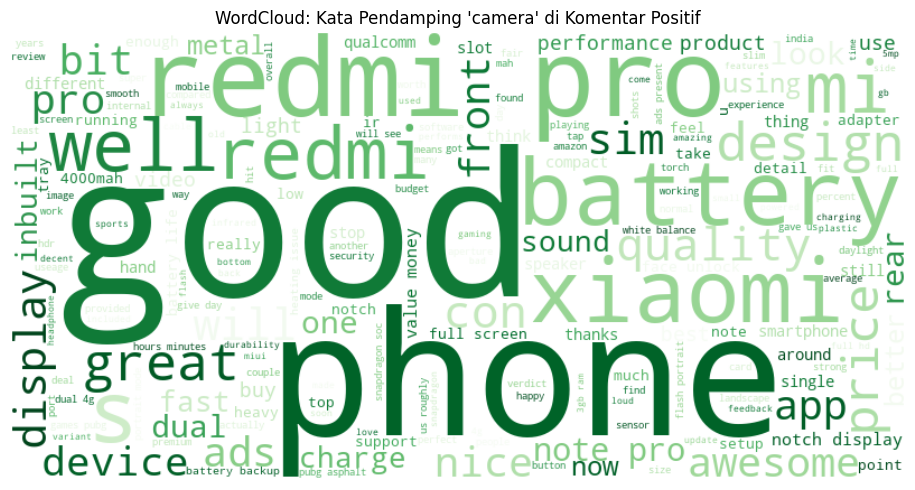

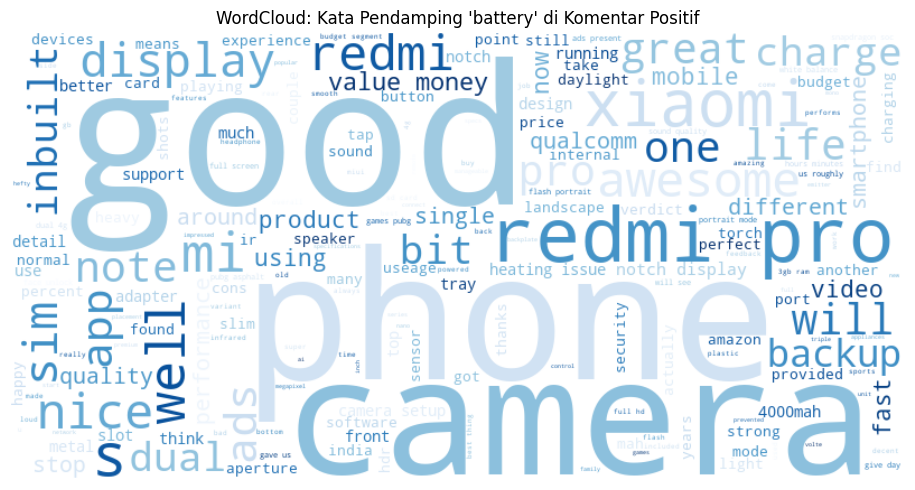

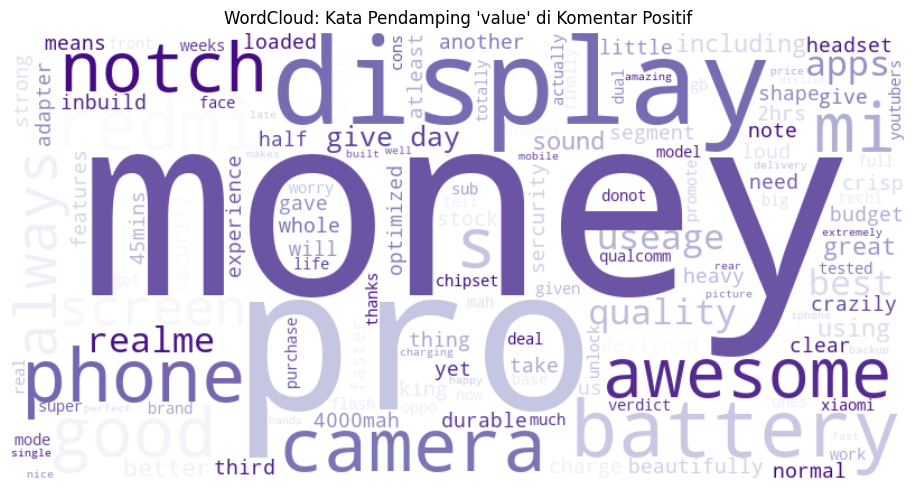

In [64]:
# === 1. Load Data ===
df = pd.read_csv("customer_feedback_labeled_final_cleaned.csv")

# === 2. Preprocessing ===
df['Rating_clean'] = df['Rating'].str.extract(r"([0-5](?:\.\d)?)").astype(float)
df['Helpful_votes'] = df['Useful'].str.extract(r'(\d+)').fillna(0).astype(int)
df['Comment_length'] = df['Comments'].astype(str).apply(lambda x: len(x.split()))
df['Date_clean'] = pd.to_datetime(df['Date'].str.replace("on ", ""), errors='coerce')
df['Month'] = df['Date_clean'].dt.to_period('M')
df['Weekday'] = df['Date_clean'].dt.day_name()
df['Sentiment'] = df['new_label_refined']

# === 3. Komentar Positif yang Mengandung Kata Tertentu ===
def extract_positive_comments_by_keyword(keyword, rating_threshold=4):
    pattern = re.compile(rf'\b{keyword}\b', re.IGNORECASE)
    return df[(df['Rating_clean'] >= rating_threshold) & df['Comments'].str.contains(pattern, na=False)]

keywords = ['camera', 'battery', 'value']
positive_comment_sets = {key: extract_positive_comments_by_keyword(key) for key in keywords}

# === 4. Hitung Kata Pendamping ===
custom_stopwords = set(STOPWORDS).union({'t', 'don', 'didn', 'doesn', 'isn', 'wasn', 'wouldn'})

def get_common_co_words(df_subset, target_keyword, n=10):
    co_words = []
    for text in df_subset['Comments'].dropna().astype(str):
        words = re.findall(r'\b\w+\b', text.lower())
        if target_keyword in words:
            co_words.extend([w for w in words if w != target_keyword and w not in custom_stopwords])
    return Counter(co_words).most_common(n)

# === 5. Tampilkan Ringkasan ===
for key in keywords:
    print(f"\n🌟 Topik Positif: {key.upper()}")
    print(f"Jumlah komentar positif yang mengandung '{key}':", len(positive_comment_sets[key]))
    print("Kata-kata yang sering muncul bersama:")
    print(get_common_co_words(positive_comment_sets[key], key))

# === 6. WordCloud kata pendamping untuk komentar positif ===
def plot_positive_wordcloud(keyword, colormap):
    df_kw = positive_comment_sets[keyword]
    text = " ".join(df_kw['Comments'].dropna().astype(str).tolist())
    text_filtered = " ".join([w for w in re.findall(r'\b\w+\b', text.lower()) if w != keyword and w not in custom_stopwords])
    wc = WordCloud(width=800, height=400, background_color='white', colormap=colormap, stopwords=custom_stopwords).generate(text_filtered)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud: Kata Pendamping '{keyword}' di Komentar Positif")
    plt.tight_layout()
    plt.show()

# Warna berbeda untuk tiap topik
topic_colors = {'camera': 'Greens', 'battery': 'Blues', 'value': 'Purples'}
for k in keywords:
    plot_positive_wordcloud(k, topic_colors[k])